In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import seaborn as sns

X_train = pd.read_pickle('../data/processed/tree_ready/X_train.pkl')
X_test = pd.read_pickle('../data/processed/tree_ready/X_test.pkl')
y_test = pd.read_pickle('../data/processed/tree_ready/y_test.pkl')

X_train_scaled = pd.read_pickle('../data/processed/neural_ready/X_train.pkl')
X_test_scaled = pd.read_pickle('../data/processed/neural_ready/X_test.pkl')

with open('../models/ml/xgboost.pkl', 'rb') as f:
    best_xgb = pickle.load(f)
with open('../models/ml/random_forest.pkl', 'rb') as f:
    best_rf = pickle.load(f)
with open('../models/ml/lightgbm.pkl', 'rb') as f:
    best_lgbm = pickle.load(f)
with open('../models/ml/logistic_regression.pkl', 'rb') as f:
    log_reg = pickle.load(f)
with open('../models/ml/svm.pkl', 'rb') as f:
    svm = pickle.load(f)

interpretation_log = []

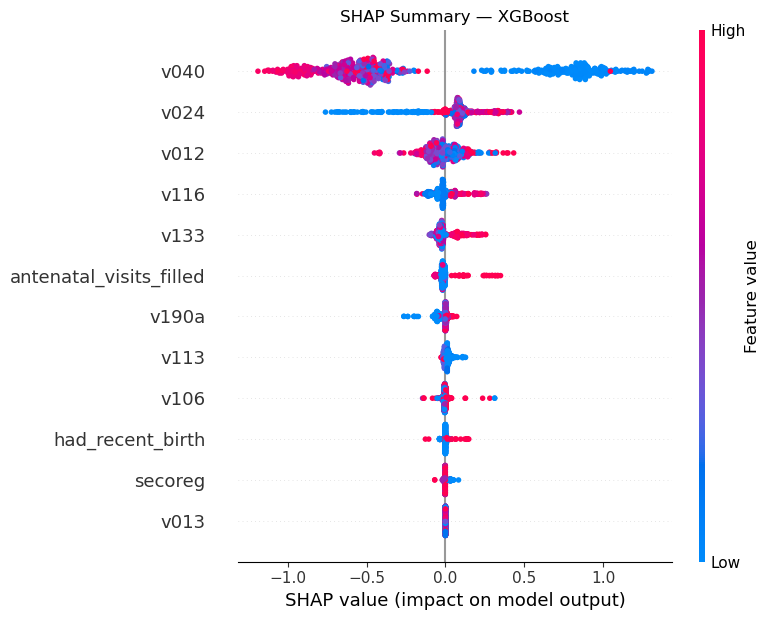

In [2]:
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.title('SHAP Summary — XGBoost')
plt.tight_layout()
plt.show()

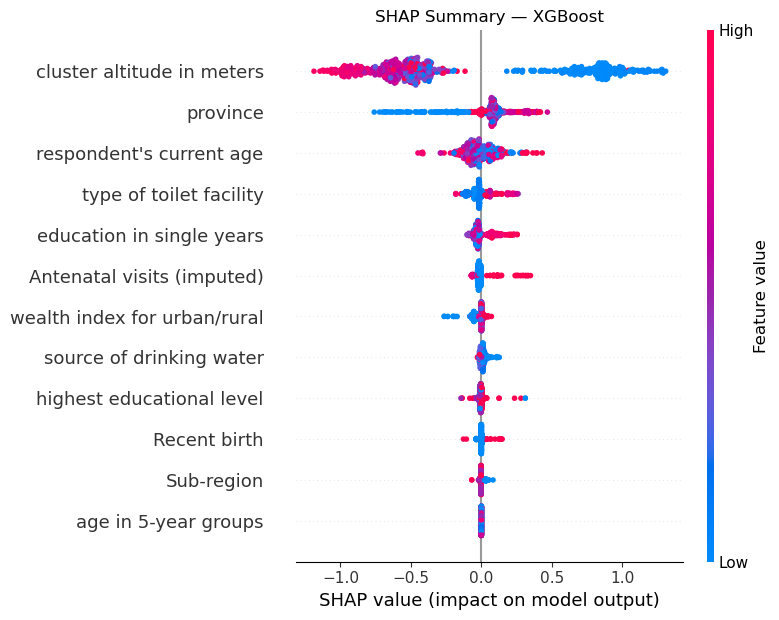

In [3]:
import json

with open('../data/interim/variable_labels.json') as f:
    labels = json.load(f)
# custom features you engineered yourself, not in the DHS codebook
custom_labels = {
    'antenatal_visits_filled': 'Antenatal visits (imputed)',
    'had_recent_birth': 'Recent birth',
    'secoreg': 'Sub-region'  # confirm this is right for your data
}
labels.update(custom_labels)

feature_names = [labels.get(col, col) for col in X_test.columns]

shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary — XGBoost')
plt.tight_layout()
plt.show()

In [7]:
X_test = pd.read_pickle('../data/processed/tree_ready/X_test.pkl')

altitude_bin = pd.cut(X_test['v040'], bins=[0, 500, 1000, 1500, 2000, 2500, 3000, 4500])
print(altitude_bin.value_counts().sort_index())

v040
(0, 500]        253
(500, 1000]     110
(1000, 1500]    146
(1500, 2000]    126
(2000, 2500]     32
(2500, 3000]      6
(3000, 4500]      2
Name: count, dtype: int64


In [11]:
print(X_test['secoreg'].value_counts())
print(X_test.groupby('secoreg')['v040'].mean())

secoreg
1    343
2    246
0     86
Name: count, dtype: int64
secoreg
0    1889.906977
1    1223.513120
2     143.410569
Name: v040, dtype: float64


          avg_risk    n
zone                   
Terai     0.491870  246
Hill      0.206997  343
Mountain  0.244186   86


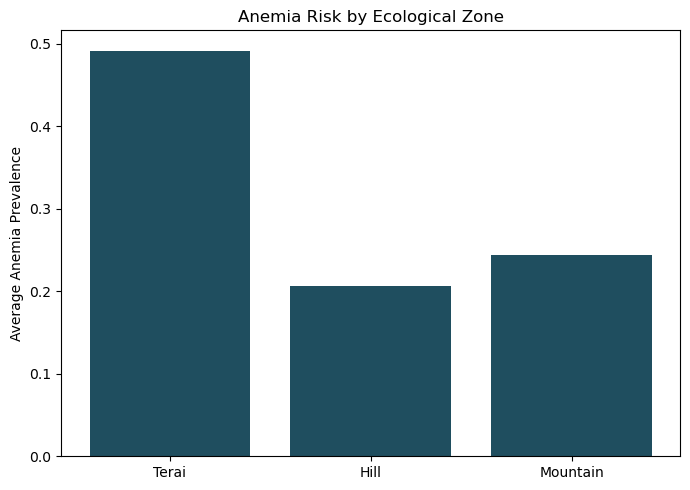

In [12]:
zone_map = {0: 'Mountain', 1: 'Hill', 2: 'Terai'}

zone = X_test['secoreg'].map(zone_map)
risk_by_zone = pd.DataFrame({'zone': zone, 'anemic': y_test.values})

summary = risk_by_zone.groupby('zone', observed=True).agg(
    avg_risk=('anemic', 'mean'),
    n=('anemic', 'size')
).reindex(['Terai', 'Hill', 'Mountain'])

print(summary)

plt.figure(figsize=(7, 5))
bars = plt.bar(summary.index, summary['avg_risk'], color='#1f4e5f')
plt.ylabel('Average Anemia Prevalence')
plt.title('Anemia Risk by Ecological Zone')
plt.tight_layout()
plt.savefig('../results/figures/anemia_by_ecological_zone.png', dpi=200)
plt.show()

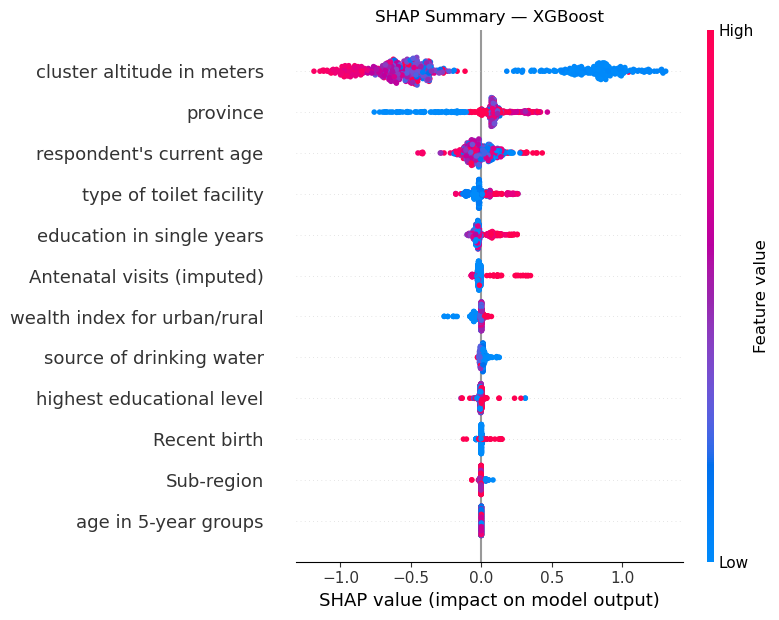

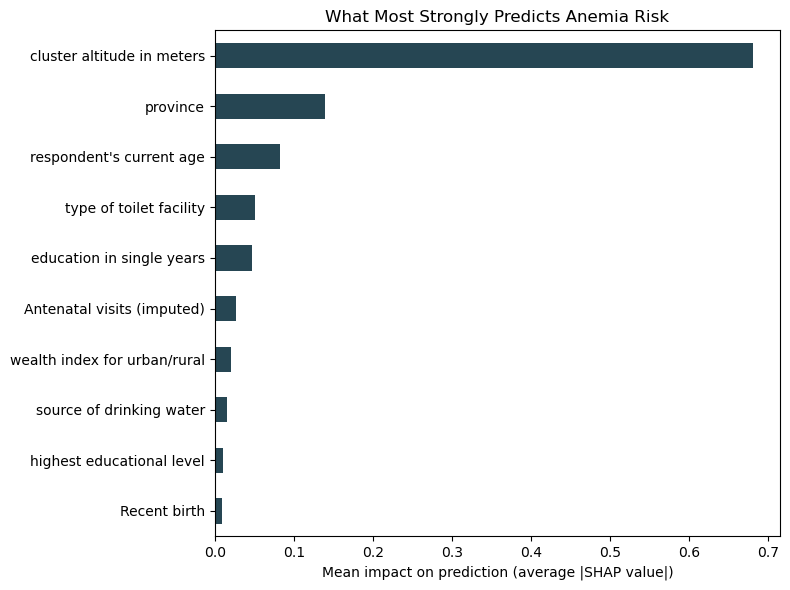

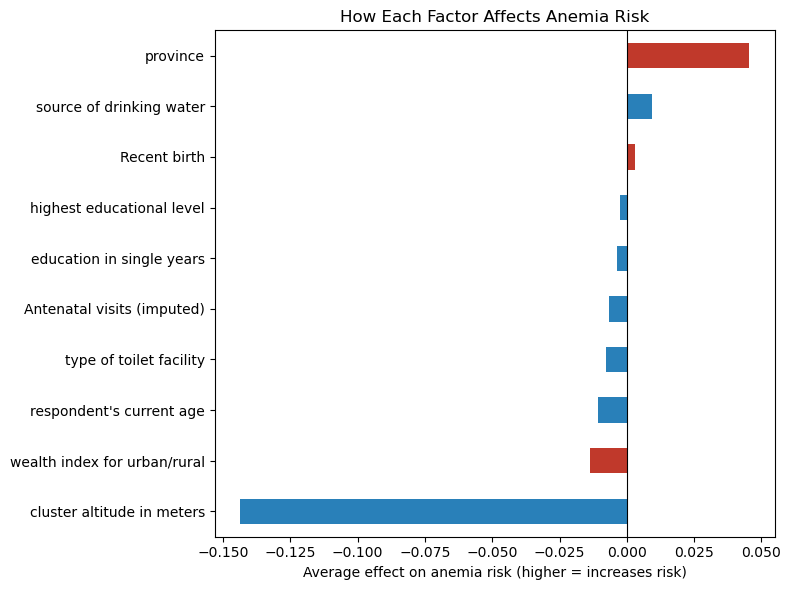

In [ ]:
import json

with open('../data/interim/variable_labels.json') as f:
    labels = json.load(f)

# custom features you engineered yourself, not in the DHS codebook
custom_labels = {
    'antenatal_visits_filled': 'Antenatal visits (imputed)',
    'had_recent_birth': 'Recent birth',
    'secoreg': 'Sub-region'  # confirm this is right for your data
}
labels.update(custom_labels)

feature_names = [labels.get(col, col) for col in X_test.columns]
label_map = dict(zip(X_test.columns, feature_names))  # reuse below

# --- Beeswarm (technical audience) ---
shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary — XGBoost')
plt.tight_layout()
plt.show()

# --- Bar chart (general-public audience) ---
mean_abs_shap = np.abs(shap_values_xgb).mean(axis=0)
top_features_xgb = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)
top_features_labeled = top_features_xgb.rename(index=label_map)

plt.figure(figsize=(8, 6))
top_features_labeled.head(10).sort_values().plot(kind='barh', color='#264653')
plt.xlabel('Mean impact on prediction (average |SHAP value|)')
plt.title('What Most Strongly Predicts Anemia Risk')
plt.tight_layout()
plt.savefig('../results/figures/shap_bar_xgb.png', dpi=200)
plt.show()

# --- Directional bar chart (bar + up/down risk, general-public friendly) ---
mean_signed_shap = pd.Series(shap_values_xgb.mean(axis=0), index=X_test.columns)
top_signed = mean_signed_shap.reindex(top_features_xgb.head(10).index).rename(index=label_map)

colors = ['#c0392b' if v > 0 else '#2980b9' for v in top_signed]
plt.figure(figsize=(8, 6))
top_signed.sort_values().plot(kind='barh', color=colors)
plt.xlabel('Average effect on anemia risk (higher = increases risk)')
plt.title('How Each Factor Affects Anemia Risk')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
mean_abs_shap = np.abs(shap_values_xgb).mean(axis=0)
top_features_xgb = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — XGBoost (Primary Model)

**Observations:**
- Top 3 features by mean |SHAP value|: {', '.join(top_features_xgb.head(3).index.tolist())}
- This ranking {"aligns with" if top_features_xgb.index[0] == 'v040' else "differs from"} the permutation importance finding in notebook 08, where v040 (altitude) was the dominant feature.

**Implication:**
- SHAP confirms which features drive individual predictions, not just aggregate model performance — useful for explaining why a specific woman was flagged as high-risk.
"""
display(Markdown(md))
interpretation_log.append(md)

### SHAP Explainability — XGBoost (Primary Model)

**Observations:**
- Top 3 features by mean |SHAP value|: v040, v024, v012
- This ranking aligns with the permutation importance finding in notebook 08, where v040 (altitude) was the dominant feature.

**Implication:**
- SHAP confirms which features drive individual predictions, not just aggregate model performance — useful for explaining why a specific woman was flagged as high-risk.


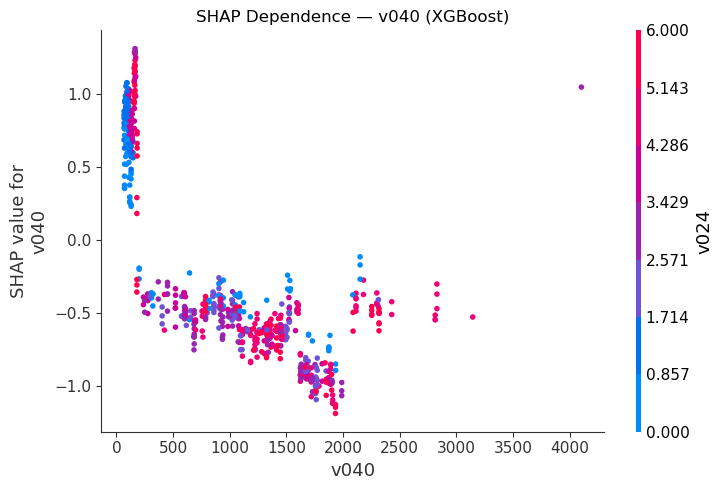

In [ ]:
top_feature = top_features_xgb.index[0]
shap.dependence_plot(top_feature, shap_values_xgb, X_test, show=False)
plt.title(f'SHAP Dependence — {top_feature} (XGBoost)')
plt.tight_layout()
plt.show()

C:\Users\Suvekshya\AppData\Local\Temp\ipykernel_195576\2239269468.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_risk_by_altitude = pd.Series(predicted_prob, index=X_test.index).groupby(altitude_binned).mean()


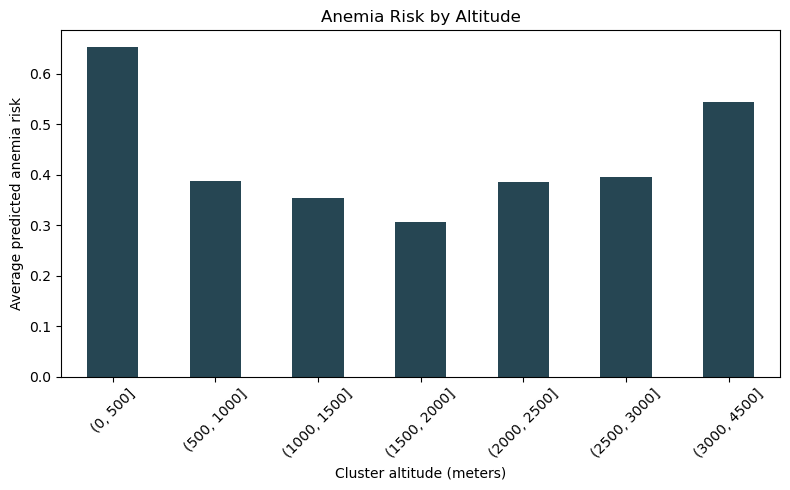

In [ ]:
bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 4500]
altitude_binned = pd.cut(X_test['v040'], bins=bins)
predicted_prob = best_xgb.predict_proba(X_test)[:, 1]

avg_risk_by_altitude = pd.Series(predicted_prob, index=X_test.index).groupby(altitude_binned).mean()

plt.figure(figsize=(8, 5))
avg_risk_by_altitude.plot(kind='bar', color='#264653')
plt.ylabel('Average predicted anemia risk')
plt.xlabel('Cluster altitude (meters)')
plt.title('Anemia Risk by Altitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/figures/anemia_risk_by_altitude.png', dpi=200)
plt.show()

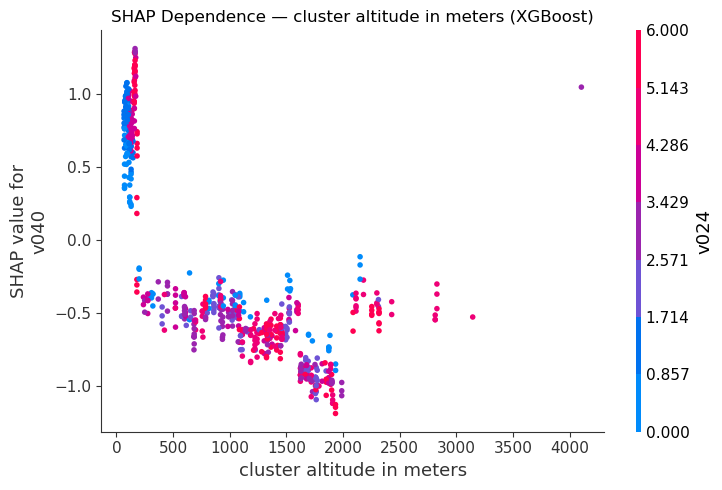

In [ ]:
top_feature = top_features_xgb.index[0]

shap.dependence_plot(top_feature, shap_values_xgb, X_test, show=False)

# get the human-readable name just for display
readable_name = labels.get(top_feature, top_feature)

plt.title(f'SHAP Dependence — {readable_name} (XGBoost)')
plt.xlabel(readable_name)
plt.tight_layout()
plt.show()

Shape used for plotting: (675, 12)


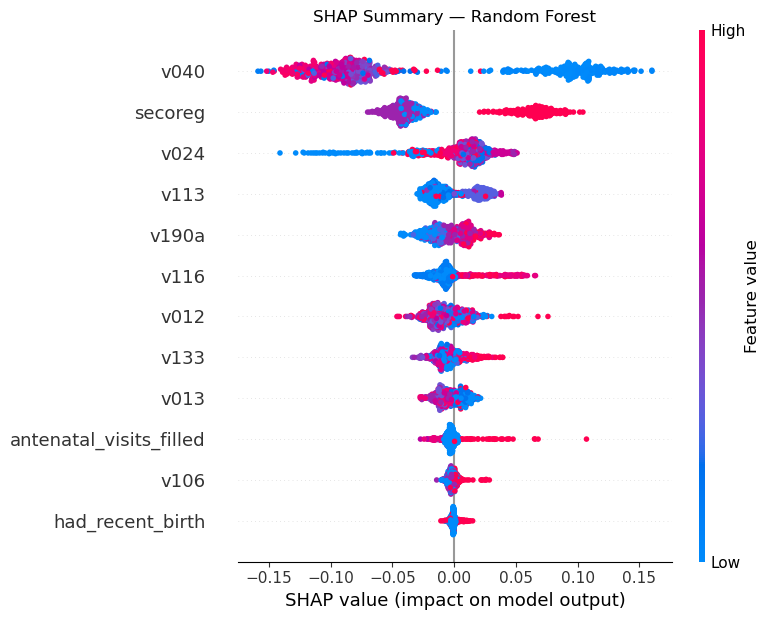

### SHAP Explainability — Random Forest

**Observations:**
- Top 3 features: v040, secoreg, v024
- Top feature overlap with XGBoost: 2 of top 5 features shared.

**Implication:**
- Some divergence between models suggests feature importance may be sensitive to model architecture — worth discussing as a limitation.


In [ ]:
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_test)

# Handle all possible SHAP output shapes across versions:
# - list of 2 arrays (older shap): [class0_array, class1_array]
# - 3D array (newer shap): (n_samples, n_features, n_classes)
# - 2D array (already single-class): (n_samples, n_features)
if isinstance(shap_values_rf, list):
    shap_values_rf_pos = shap_values_rf[1]
elif shap_values_rf.ndim == 3:
    shap_values_rf_pos = shap_values_rf[:, :, 1]
else:
    shap_values_rf_pos = shap_values_rf

print("Shape used for plotting:", shap_values_rf_pos.shape)

shap.summary_plot(shap_values_rf_pos, X_test, show=False)
plt.title('SHAP Summary — Random Forest')
plt.tight_layout()
plt.show()

top_features_rf = pd.Series(np.abs(shap_values_rf_pos).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — Random Forest

**Observations:**
- Top 3 features: {', '.join(top_features_rf.head(3).index.tolist())}
- Top feature overlap with XGBoost: {len(set(top_features_xgb.head(5).index) & set(top_features_rf.head(5).index))} of top 5 features shared.

**Implication:**
- {"Strong agreement across tree-based models increases confidence these features are genuinely predictive, not model-specific artifacts." if len(set(top_features_xgb.head(5).index) & set(top_features_rf.head(5).index)) >= 3 else "Some divergence between models suggests feature importance may be sensitive to model architecture — worth discussing as a limitation."}
"""
display(Markdown(md))
interpretation_log.append(md)

c:\Users\Suvekshya\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


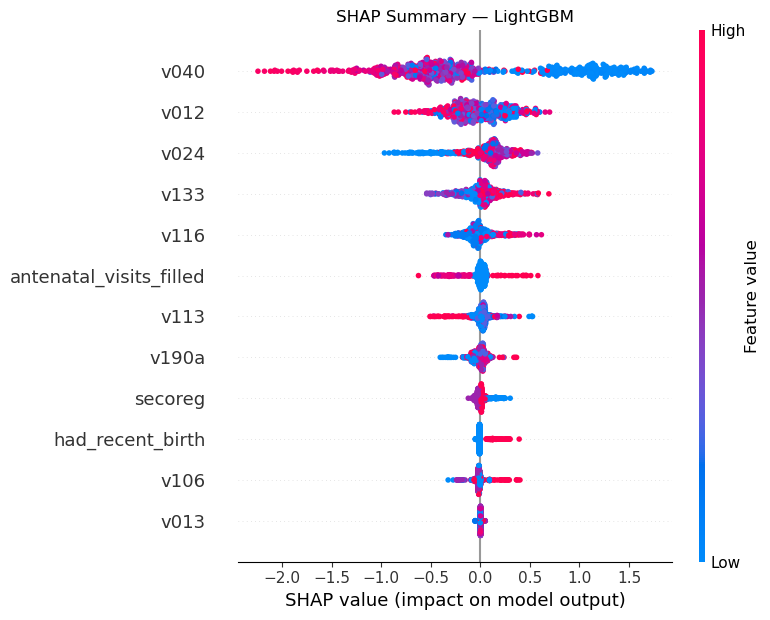

### SHAP Explainability — LightGBM

**Observations:**
- Top 3 features: v040, v012, v024


In [ ]:
explainer_lgbm = shap.TreeExplainer(best_lgbm)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)

if isinstance(shap_values_lgbm, list):
    shap_values_lgbm_pos = shap_values_lgbm[1]
elif shap_values_lgbm.ndim == 3:
    shap_values_lgbm_pos = shap_values_lgbm[:, :, 1]
else:
    shap_values_lgbm_pos = shap_values_lgbm

shap.summary_plot(shap_values_lgbm_pos, X_test, show=False)
plt.title('SHAP Summary — LightGBM')
plt.tight_layout()
plt.show()

top_features_lgbm = pd.Series(np.abs(shap_values_lgbm_pos).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — LightGBM

**Observations:**
- Top 3 features: {', '.join(top_features_lgbm.head(3).index.tolist())}
"""
display(Markdown(md))
interpretation_log.append(md)

Background dataset has 2696 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2696 when initializing the masker.


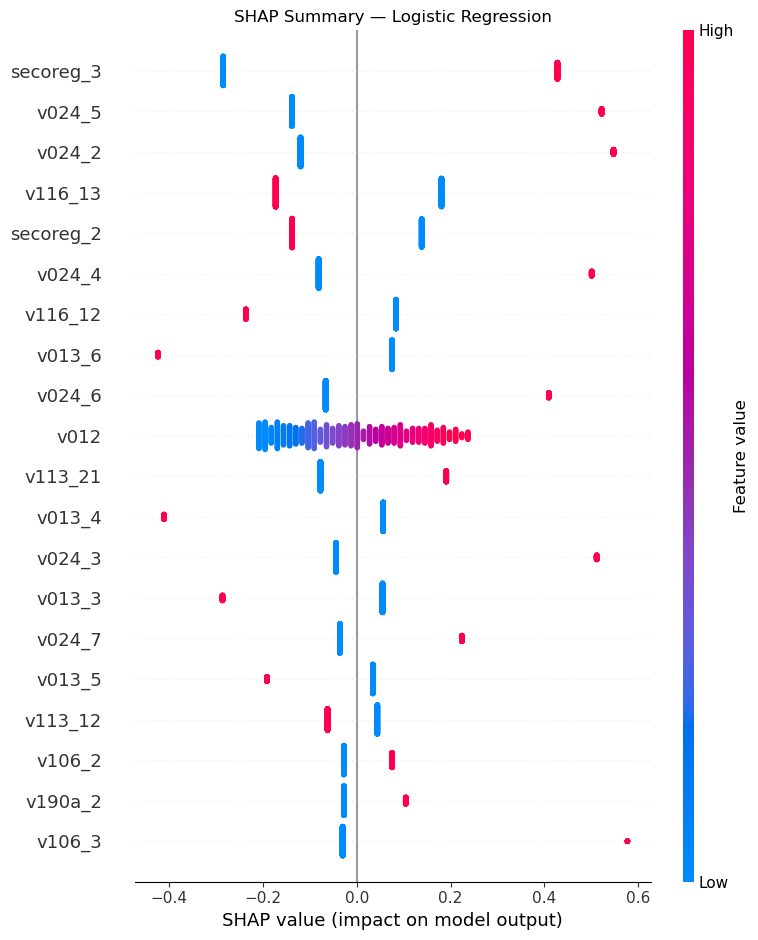

### SHAP Explainability — Logistic Regression

**Observations:**
- Top 3 features: secoreg_3, v024_5, v024_2

**Implication:**
- Since Logistic Regression is linear, SHAP values here directly reflect each feature's coefficient-weighted contribution — a useful, more transparent cross-check against the tree-based models' nonlinear explanations.


In [ ]:
explainer_lr = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

shap.summary_plot(shap_values_lr, X_test_scaled, show=False)
plt.title('SHAP Summary — Logistic Regression')
plt.tight_layout()
plt.show()

top_features_lr = pd.Series(np.abs(shap_values_lr).mean(axis=0), index=X_test_scaled.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — Logistic Regression

**Observations:**
- Top 3 features: {', '.join(top_features_lr.head(3).index.tolist())}

**Implication:**
- Since Logistic Regression is linear, SHAP values here directly reflect each feature's coefficient-weighted contribution — a useful, more transparent cross-check against the tree-based models' nonlinear explanations.
"""
display(Markdown(md))
interpretation_log.append(md)

  0%|          | 0/100 [00:00<?, ?it/s]

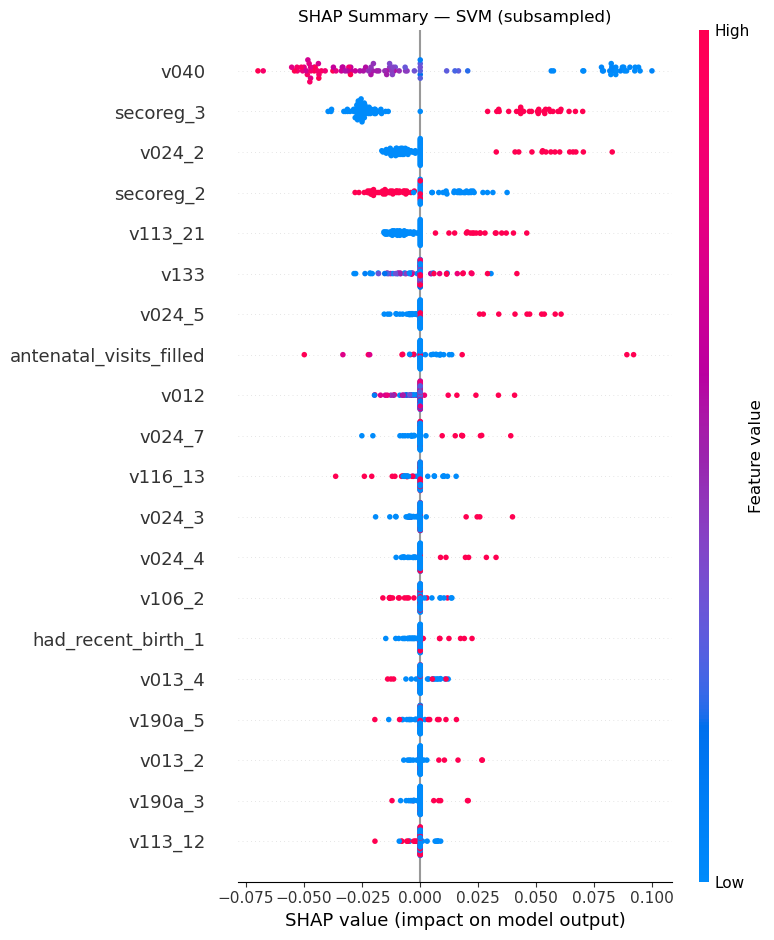

### SHAP Explainability — SVM (Best Recall Model)

**Observations:**
- Top 3 features: v040, secoreg_3, v024_2
- Note: computed on a 100-row test subsample (of 675 total) due to KernelExplainer's computational cost — treat as directionally indicative rather than exhaustive.

**Implication:**
- SVM achieved the best recall of all models; understanding what drives its predictions is valuable even though its explanation is less precise than the tree-based SHAP results.


In [ ]:
background = shap.sample(X_train_scaled.astype(float), 50, random_state=42)
test_sample = X_test_scaled.astype(float).sample(100, random_state=42)

explainer_svm = shap.KernelExplainer(svm.predict_proba, background)
shap_values_svm = explainer_svm.shap_values(test_sample, nsamples=100)

if isinstance(shap_values_svm, list):
    shap_values_svm_pos = shap_values_svm[1]
elif np.array(shap_values_svm).ndim == 3:
    shap_values_svm_pos = np.array(shap_values_svm)[:, :, 1]
else:
    shap_values_svm_pos = shap_values_svm

shap.summary_plot(shap_values_svm_pos, test_sample, show=False)
plt.title('SHAP Summary — SVM (subsampled)')
plt.tight_layout()
plt.show()

top_features_svm = pd.Series(np.abs(shap_values_svm_pos).mean(axis=0), index=test_sample.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — SVM (Best Recall Model)

**Observations:**
- Top 3 features: {', '.join(top_features_svm.head(3).index.tolist())}
- Note: computed on a 100-row test subsample (of {len(X_test_scaled)} total) due to KernelExplainer's computational cost — treat as directionally indicative rather than exhaustive.

**Implication:**
- SVM achieved the best recall of all models; understanding what drives its predictions is valuable even though its explanation is less precise than the tree-based SHAP results.
"""
display(Markdown(md))
interpretation_log.append(md)

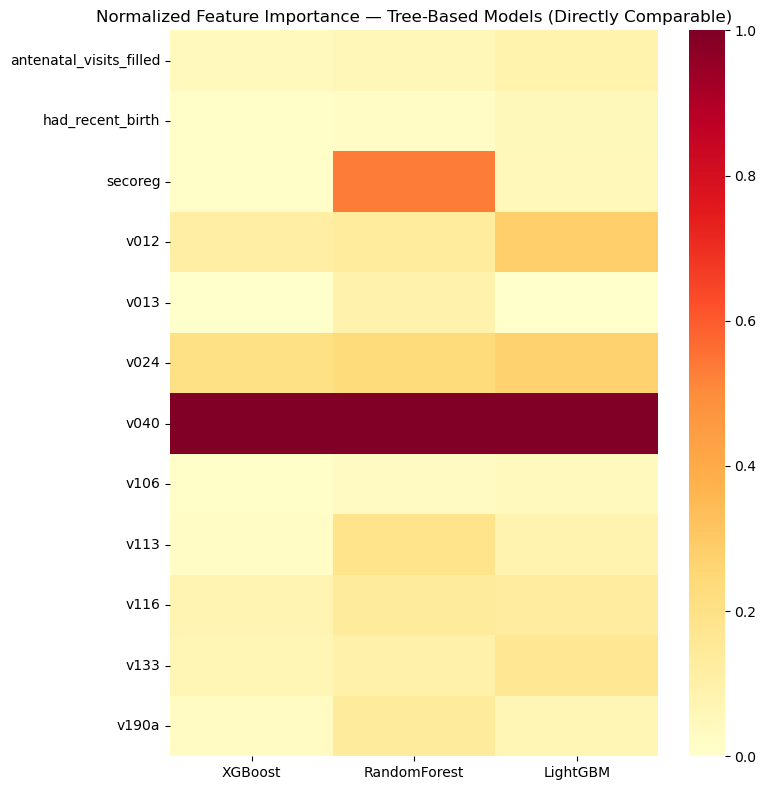

### Cross-Model SHAP Comparison — Tree-Based Models

**Observations:**
- Features consistently important across XGBoost, Random Forest, and LightGBM: v040, v024, secoreg
- These three models share identical (label-encoded) feature representations, making this comparison directly valid — unlike a comparison including one-hot encoded linear/SVM models, which use a different feature space and are not row-aligned.

**Implication for the study's core contribution:**
- Strong agreement across three structurally different tree-based algorithms (bagging, and two boosting variants) provides robust evidence that altitude, geography, and age are genuine drivers of anemia risk in this population, not artifacts of any single model's architecture.
- Logistic Regression and SVM results (reported separately, in one-hot feature space) corroborate this at the conceptual level — geography and age dominate there too — even though their exact features aren't directly poolable into this heatmap.


Saved to ../data/processed/explainability_interpretation.txt


In [ ]:
comparison_trees = pd.DataFrame({
    'XGBoost': top_features_xgb,
    'RandomForest': top_features_rf,
    'LightGBM': top_features_lgbm,
}).fillna(0)

comparison_trees_norm = comparison_trees / comparison_trees.max()

plt.figure(figsize=(8, 8))
sns.heatmap(comparison_trees_norm, annot=False, cmap='YlOrRd')
plt.title('Normalized Feature Importance — Tree-Based Models (Directly Comparable)')
plt.tight_layout()
plt.show()

comparison_trees.to_csv('../results/metrics/shap_importance_tree_models.csv')

top_agreement = comparison_trees_norm.mean(axis=1).sort_values(ascending=False).head(3)

md_final = f"""### Cross-Model SHAP Comparison — Tree-Based Models

**Observations:**
- Features consistently important across XGBoost, Random Forest, and LightGBM: {', '.join(top_agreement.index.tolist())}
- These three models share identical (label-encoded) feature representations, making this comparison directly valid — unlike a comparison including one-hot encoded linear/SVM models, which use a different feature space and are not row-aligned.

**Implication for the study's core contribution:**
- Strong agreement across three structurally different tree-based algorithms (bagging, and two boosting variants) provides robust evidence that altitude, geography, and age are genuine drivers of anemia risk in this population, not artifacts of any single model's architecture.
- Logistic Regression and SVM results (reported separately, in one-hot feature space) corroborate this at the conceptual level — geography and age dominate there too — even though their exact features aren't directly poolable into this heatmap.
"""
display(Markdown(md_final))
interpretation_log.append(md_final)

# Re-save with the corrected comparison
output_path = '../data/processed/explainability_interpretation.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write('\n\n---\n\n'.join(interpretation_log))
print(f"Saved to {output_path}")

In [ ]:
output_path = '../data/processed/explainability_interpretation.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write('\n\n---\n\n'.join(interpretation_log))
print(f"Saved to {output_path}")

Saved to ../data/processed/explainability_interpretation.txt
